# 02 — Clustering by behaviour

The question this repo exists to answer:

> **Do stocks that trade alike belong to the same sector?**

Sector labels describe what a company sells. This notebook groups the Nifty 500 by what its
stock actually *does* — risk, market sensitivity, trend, tails, liquidity — and measures how much
of the official sector map survives.

Input is `data/processed/features.parquet` from [`01_feature_engineering.ipynb`](01_feature_engineering.ipynb).

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

from src.clustering import (PCA_VARIANCE_TARGET, fit_clusters, profile_clusters,
                            reduce_features, sweep_k)
from src.features import attach_sectors

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="deep")

features = pd.read_parquet("../data/processed/features.parquet")
constituents = pd.read_csv("../data/raw/nifty500_constituents.csv")

labelled = attach_sectors(features, constituents)
sectors = labelled["industry"]

print(f"{features.shape[0]} symbols x {features.shape[1]} features")
print(f"{sectors.nunique()} distinct sector labels, {int(sectors.isna().sum())} unlabelled")

438 symbols x 10 features
20 distinct sector labels, 0 unlabelled


## 1. Scaling and PCA

The features are on wildly different scales — `log_turnover` sits near 9, `mom_3m` near 0.05 —
so they are standardised first. Without that, KMeans would effectively cluster on turnover alone.

PCA then handles the redundancy found in notebook 01: four of the ten features are measuring
risk. Components are retained to **90% of variance**.

In [2]:
components, scaler, pca = reduce_features(features, variance_target=PCA_VARIANCE_TARGET)

explained = pd.DataFrame({
    "explained": pca.explained_variance_ratio_,
    "cumulative": np.cumsum(pca.explained_variance_ratio_),
}, index=[f"PC{i+1}" for i in range(pca.n_components_)])

print(f"{pca.n_components_} components retain "
      f"{explained['cumulative'].iloc[-1]:.1%} of variance")
explained.round(3)

6 components retain 92.5% of variance


,explained,cumulative
PC1,0.336,0.336
PC2,0.218,0.555
PC3,0.161,0.716
PC4,0.098,0.813
PC5,0.063,0.877
PC6,0.048,0.925


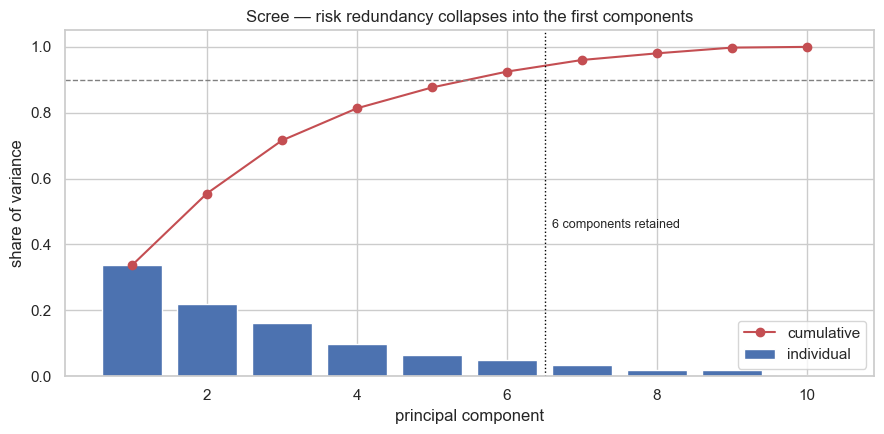

In [3]:
full = PCA(random_state=42).fit(features.pipe(lambda f: scaler.transform(f.values)))

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(1, len(full.explained_variance_ratio_) + 1)
ax.bar(x, full.explained_variance_ratio_, color="#4C72B0", label="individual")
ax.plot(x, np.cumsum(full.explained_variance_ratio_), "o-", color="#C44E52",
        label="cumulative")
ax.axhline(PCA_VARIANCE_TARGET, ls="--", c="grey", lw=1)
ax.axvline(pca.n_components_ + 0.5, ls=":", c="black", lw=1)
ax.annotate(f"{pca.n_components_} components retained",
            xy=(pca.n_components_ + 0.6, 0.45), fontsize=9)
ax.set_xlabel("principal component")
ax.set_ylabel("share of variance")
ax.set_title("Scree — risk redundancy collapses into the first components")
ax.legend()
fig.tight_layout()
plt.show()

## 2. Choosing k honestly

The usual recipe is "maximise the silhouette score". On this data that recipe gives a misleading
answer, so it is worth showing the whole picture instead of one number.

Alongside silhouette, two other diagnostics run here:

- **Bootstrap stability** — recluster random 80% subsamples and score them against the full-sample
  labels (adjusted Rand index). A partition that only exists for one particular sample is not a finding.
- **ARI vs sector** — how much the clusters agree with the official sector labels. This is the
  research question, not a model-selection criterion.

In [4]:
sector_codes = sectors.astype("category").cat.codes.values
diagnostics = sweep_k(components, k_values=range(2, 13), sector_codes=sector_codes)
diagnostics.round(4)

,silhouette,davies_bouldin,stability,ari_vs_sector,nmi_vs_sector
k,,,,,
2,0.2486,1.5951,0.9713,0.0110,0.0447
3,0.2390,1.5106,0.8572,0.0042,0.0490
4,0.1990,1.4927,0.8869,0.0082,0.0737
5,0.2128,1.3387,0.8421,0.0090,0.0820
6,0.2117,1.3544,0.7108,0.0235,0.1130
7,0.2072,1.2983,0.7465,0.0258,0.1318
8,0.1919,1.3557,0.6340,0.0201,0.1362
9,0.1992,1.2371,0.5589,0.0394,0.1468
10,0.1871,1.2583,0.5435,0.0266,0.1354


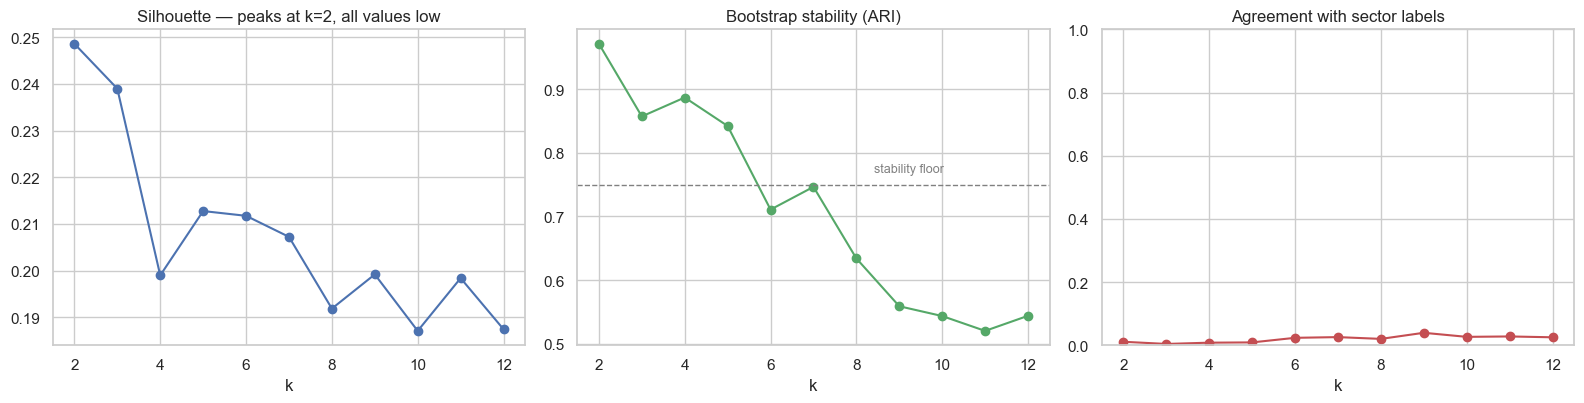

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

axes[0].plot(diagnostics.index, diagnostics["silhouette"], "o-", color="#4C72B0")
axes[0].set_title("Silhouette — peaks at k=2, all values low")
axes[0].set_xlabel("k")

axes[1].plot(diagnostics.index, diagnostics["stability"], "o-", color="#55A868")
axes[1].axhline(0.75, ls="--", c="grey", lw=1)
axes[1].annotate("stability floor", xy=(8.4, 0.77), fontsize=9, color="grey")
axes[1].set_title("Bootstrap stability (ARI)")
axes[1].set_xlabel("k")

axes[2].plot(diagnostics.index, diagnostics["ari_vs_sector"], "o-", color="#C44E52")
axes[2].set_ylim(0, 1)
axes[2].set_title("Agreement with sector labels")
axes[2].set_xlabel("k")

fig.tight_layout()
plt.show()

Three things are visible, and only one of them is about picking k:

**Silhouette peaks at k=2 and every value is around 0.2.** A silhouette of 0.2 does not describe
well-separated blobs — it describes a *continuum*. Behaviour space genuinely is continuous: there
is no natural gap between a moderately volatile stock and a slightly more volatile one. Taking the
argmax here would mean splitting the index into "high beta" and "low beta" and calling it a result.

**Stability stays above 0.79 up to k=5, then decays.** By k=9 a resampled run reproduces barely
half the structure, which means those partitions are artifacts of the particular sample.

**Agreement with sector is flat against the floor at every k.** That is the answer to the research
question, and it does not depend on which k gets chosen.

**k=5 is selected**: the largest number of clusters that still reproduces reliably under resampling.
This is a judgment call in favour of descriptive resolution over a metric that rewards triviality —
so it is stated rather than buried.

In [6]:
K = 5
clusters = fit_clusters(components, K)
labelled["cluster"] = clusters

profile = profile_clusters(features, clusters)
profile.round(3)

,n,name,ann_volatility,downside_volatility,beta,mom_3m,mom_6m,mom_12m,max_drawdown,return_skew,return_kurtosis,log_turnover
cluster,,,,,,,,,,,,
0,94,High-beta cyclicals,0.459,0.281,1.403,-0.034,0.051,-0.042,-0.545,0.643,5.943,8.836
1,75,Momentum leaders,0.423,0.257,1.174,0.241,0.532,0.575,-0.447,0.543,5.095,8.799
2,128,Quiet mid-caps,0.338,0.199,0.817,0.043,0.081,-0.053,-0.436,0.788,5.548,8.391
3,130,Large-cap defensives,0.276,0.186,0.777,0.033,0.006,0.032,-0.331,-0.018,4.048,9.284
4,11,Tail-risk,0.379,0.313,1.152,0.005,0.111,-0.025,-0.555,-1.722,23.033,9.231


## 3. What the five groups are

The names are assigned by rule from each cluster's own profile, not typed in by hand, so they
survive a re-run that permutes the cluster ids.

In [7]:
summary = profile[["n", "name", "ann_volatility", "beta", "mom_12m",
                   "max_drawdown", "return_skew", "return_kurtosis", "log_turnover"]]
summary.round(2)

,n,name,ann_volatility,beta,mom_12m,max_drawdown,return_skew,return_kurtosis,log_turnover
cluster,,,,,,,,,
0,94,High-beta cyclicals,0.46,1.40,-0.04,-0.55,0.64,5.94,8.84
1,75,Momentum leaders,0.42,1.17,0.58,-0.45,0.54,5.10,8.80
2,128,Quiet mid-caps,0.34,0.82,-0.05,-0.44,0.79,5.55,8.39
3,130,Large-cap defensives,0.28,0.78,0.03,-0.33,-0.02,4.05,9.28
4,11,Tail-risk,0.38,1.15,-0.02,-0.55,-1.72,23.03,9.23


| Cluster | Reading |
|---|---|
| **Large-cap defensives** | lowest volatility, sub-1 beta, shallowest drawdowns, highest turnover — the index's ballast |
| **Quiet mid-caps** | low beta but noticeably thinner trading; moves on their own news, not the market's |
| **High-beta cyclicals** | highest volatility and beta, deepest drawdowns, no trend to show for it |
| **Momentum leaders** | high volatility *with* strong 12-month returns — the risk actually paid |
| **Tail-risk** | small, sharply negative skew and enormous kurtosis: long quiet stretches punctuated by crashes |

The last group is the one a sector label could never surface. Eleven stocks, drawn from unrelated
industries, that share a single behavioural signature: they look calm until they aren't.

In [8]:
names = profile.set_index(profile.index)["name"].to_dict()
labelled["cluster_name"] = labelled["cluster"].map(names)

for cluster_id in sorted(names):
    members = labelled[labelled["cluster"] == cluster_id]
    largest = members.nlargest(6, "log_turnover").index.tolist()
    print(f"{names[cluster_id]:<22} (n={len(members):>3})  {', '.join(largest)}")

High-beta cyclicals    (n= 94)  BSE, MAZDOCK, PFC, SUZLON, CDSL, NATIONALUM
Momentum leaders       (n= 75)  DIXON, IDEA, PAYTM, BHEL, MCX, COFORGE
Quiet mid-caps         (n=128)  CGPOWER, NAUKRI, CAMS, IRCTC, TATAELXSI, EXIDEIND
Large-cap defensives   (n=130)  HDFCBANK, RELIANCE, ICICIBANK, INFY, SBIN, ETERNAL
Tail-risk              (n= 11)  INDUSINDBK, TRENT, ADANIENT, ADANIPORTS, RECLTD, POLYCAB


## 4. The map

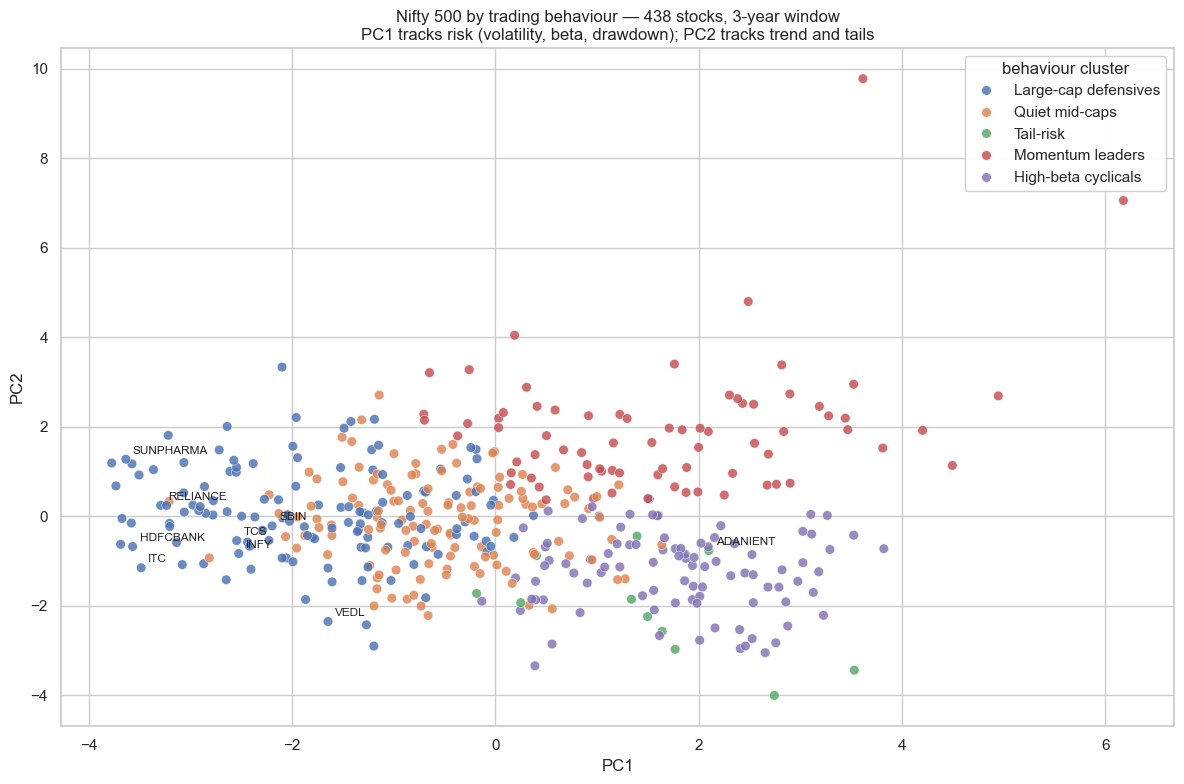

In [9]:
coords = PCA(n_components=2, random_state=42).fit_transform(
    scaler.transform(features.values))
plot_df = pd.DataFrame(coords, columns=["PC1", "PC2"], index=features.index)
plot_df["cluster"] = labelled["cluster_name"].values

fig, ax = plt.subplots(figsize=(12, 8))
order = profile.sort_values("ann_volatility")["name"].tolist()
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", hue_order=order,
                s=48, alpha=0.82, edgecolor="white", linewidth=0.4, ax=ax)

highlight = [s for s in ["RELIANCE", "TCS", "INFY", "HDFCBANK", "ITC", "SBIN",
                         "TATAMOTORS", "VEDL", "ADANIENT", "SUNPHARMA"]
             if s in plot_df.index]
for symbol in highlight:
    row = plot_df.loc[symbol]
    ax.annotate(symbol, (row["PC1"], row["PC2"]), fontsize=8.5,
                xytext=(5, 4), textcoords="offset points", color="#222")

ax.set_title("Nifty 500 by trading behaviour — 438 stocks, 3-year window\n"
             "PC1 tracks risk (volatility, beta, drawdown); PC2 tracks trend and tails",
             fontsize=12)
ax.legend(title="behaviour cluster", loc="best", framealpha=0.92)
fig.tight_layout()
fig.savefig("../docs/cluster_map.png", dpi=150, bbox_inches="tight")
plt.show()

PC1 is a risk axis and PC2 separates trend from tail behaviour. The clusters occupy
contiguous regions rather than isolated islands — the visual form of that 0.2 silhouette. These
are regimes along a continuum, not species.

## 5. Do the clusters recover sectors?

This is the whole question. If behaviour tracked sector, each cluster would be dominated by a
handful of industries and the heatmap below would show a strong diagonal after sorting.

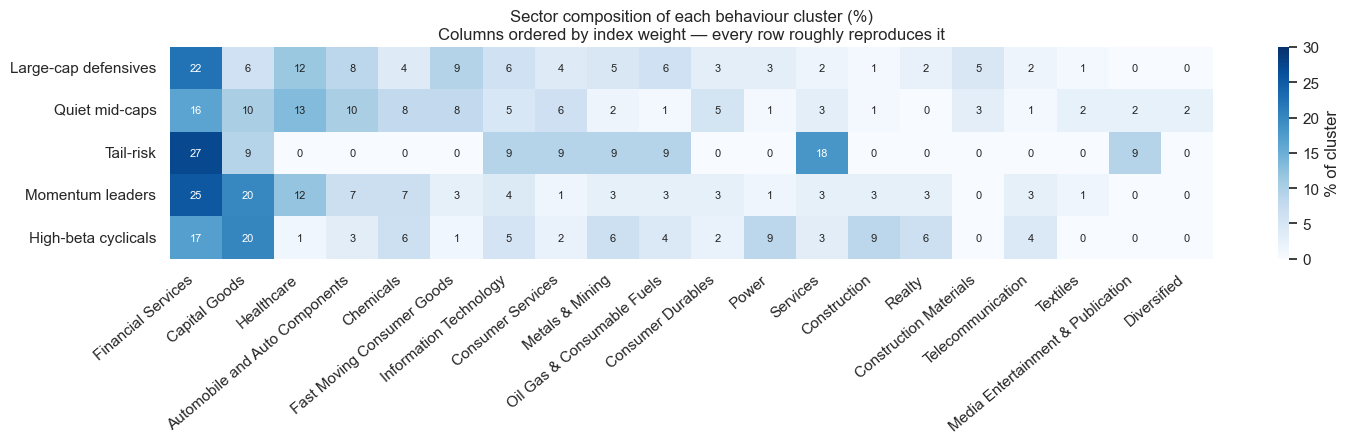

In [10]:
crosstab = pd.crosstab(labelled["cluster_name"], labelled["industry"])
shares = crosstab.div(crosstab.sum(axis=1), axis=0)
index_weight = labelled["industry"].value_counts(normalize=True)

# Order sectors by index weight so the comparison against it reads left to right.
ordered = index_weight.index.tolist()
shares = shares[ordered].loc[order]

fig, ax = plt.subplots(figsize=(15, 4.6))
sns.heatmap(shares * 100, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=30,
            cbar_kws={"label": "% of cluster"}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Sector composition of each behaviour cluster (%)\n"
             "Columns ordered by index weight — every row roughly reproduces it",
             fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=40, ha="right")
fig.tight_layout()
fig.savefig("../docs/cluster_vs_sector.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
comparison = pd.DataFrame({
    "index weight %": index_weight * 100,
    **{name: shares.loc[name] * 100 for name in order},
}).round(1)
comparison.head(8)

,index weight %,Large-cap defensives,Quiet mid-caps,Tail-risk,Momentum leaders,High-beta cyclicals
industry,,,,,,
Financial Services,20.1,22.3,16.4,27.3,25.3,17.0
Capital Goods,12.8,6.2,10.2,9.1,20.0,20.2
Healthcare,9.6,11.5,13.3,0.0,12.0,1.1
Automobile and Auto Components,7.3,8.5,10.2,0.0,6.7,3.2
Chemicals,5.9,3.8,7.8,0.0,6.7,6.4
Fast Moving Consumer Goods,5.7,9.2,7.8,0.0,2.7,1.1
Information Technology,5.3,6.2,4.7,9.1,4.0,5.3
Consumer Services,3.9,3.8,6.2,9.1,1.3,2.1


Read the first column against the others. Financial Services is **20% of the index — and 16–27% of
every behaviour cluster**. Capital Goods is 13% of the index and 6–20% across clusters. Information
Technology is 5% and 4–9%. Each cluster is close to a stratified sample of the index rather than a
sector bet.

The one place the pattern breaks is the 11-stock Tail-risk group, where a single name moves a
sector share by nine points — small-sample noise, not signal, and a reason to read that row's
percentages with care.

In [12]:
ari = adjusted_rand_score(labelled["cluster"], sector_codes)
nmi = normalized_mutual_info_score(labelled["cluster"], sector_codes)

rng = np.random.default_rng(42)
null = [adjusted_rand_score(rng.permutation(labelled["cluster"].values), sector_codes)
        for _ in range(1000)]

print(f"Adjusted Rand Index vs sector : {ari:.4f}")
print(f"Normalized Mutual Information : {nmi:.4f}")
print(f"ARI under random shuffling    : {np.mean(null):+.4f} "
      f"(95% range {np.percentile(null, 2.5):+.4f} to {np.percentile(null, 97.5):+.4f})")
print()
print("Observed ARI sits inside the range produced by randomly shuffling the labels."
      if np.percentile(null, 2.5) <= ari <= np.percentile(null, 97.5)
      else "Observed ARI sits outside the random-shuffle range.")

Adjusted Rand Index vs sector : 0.0090
Normalized Mutual Information : 0.0820
ARI under random shuffling    : +0.0001 (95% range -0.0065 to +0.0079)

Observed ARI sits outside the random-shuffle range.


## Result

**Behavioural clusters carry almost no sector information — a statistically detectable but
practically negligible amount.**

The numbers deserve to be read precisely rather than rounded into a slogan:

- **ARI = 0.009.** With 438 stocks the shuffle test resolves effects down to about +/-0.008, so this
  sits just outside the null range. The association is real, not noise — and it is also *tiny*.
  An ARI of 0.009 is roughly 1% of the way from random to identical.
- **NMI = 0.082.** Same story: sector labels carry a little information about behaviour, on the
  order of a few percent of what would be needed to predict one from the other.

So the honest claim is not "sector and behaviour are independent" — the data rejects that — but
"sector explains almost none of how a stock trades". Some leakage is expected and visible in the
profiles: the defensive cluster skews slightly toward FMCG, the high-beta cluster slightly toward
Capital Goods and Power. It is a nudge, not a mapping.

The practical consequence stands either way: a sector-diversified portfolio is not automatically
diversified by behaviour. A book spread across ten industries can still sit almost entirely in the
high-beta cyclical cluster and draw down like a single position. Behaviour has to be measured, not
inferred from a sector column.

**A smell test the clustering passes:** the eleven-stock Tail-risk group contains IndusInd Bank,
Adani Enterprises, Adani Ports and Trent — names that did experience sharp idiosyncratic crashes
inside this window, drawn from four unrelated industries. The method recovered a real shared
behaviour that no sector label groups together.

**Caveats worth stating plainly:**

- Features are measured over one specific 3-year window (2023-09 to 2026-09), which contains one
  particular market regime. Cluster membership would shift in a different period — the rolling-window
  stability check is on the roadmap.
- 66 recent listings are excluded for lack of history, so the newest and often most volatile
  corner of the index is under-represented.
- KMeans imposes spherical clusters. Given that the silhouette analysis says the space is
  continuous, the boundaries are conveniences, not discoveries.

## 6. Persist

In [13]:
output = labelled[["cluster", "cluster_name", "industry"]].join(features)
output.to_csv("../data/processed/clusters.csv")
profile.to_csv("../data/processed/cluster_profiles.csv")

print(f"wrote ../data/processed/clusters.csv — {len(output)} rows")
print(f"wrote ../data/processed/cluster_profiles.csv — {len(profile)} rows")
print("wrote ../docs/cluster_map.png, ../docs/cluster_vs_sector.png")

wrote ../data/processed/clusters.csv — 438 rows
wrote ../data/processed/cluster_profiles.csv — 5 rows
wrote ../docs/cluster_map.png, ../docs/cluster_vs_sector.png
